In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import itertools
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

In [ ]:
time_series = pd.read_csv('time_series.csv')

In [3]:
time_series['date'] = pd.to_datetime(time_series['date'])

In [4]:
#### set the date as index
time_series = time_series.set_index('date')

In [5]:
####Previously revenue by week now this sorted revenue by month
monthly_series= time_series.total_revenue.resample('ME').sum()

<Axes: xlabel='date'>

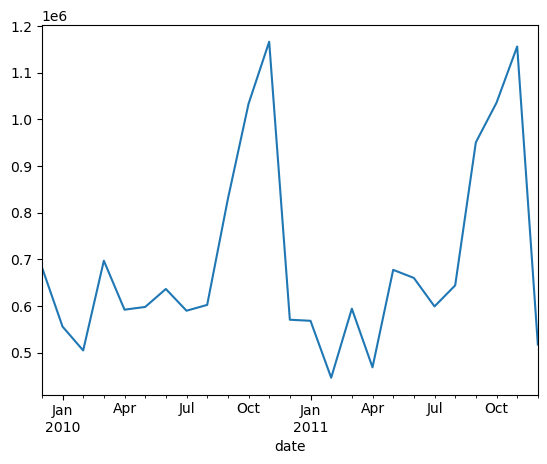

In [6]:
monthly_series.plot()

In [7]:
# SECTION 1 — TRAIN / TEST SPLIT
# Hold out last 5 months as test set


TEST_STEPS = 5  # last 5 months

train = monthly_series.iloc[:-TEST_STEPS]
test  = monthly_series.iloc[-TEST_STEPS:]

print(f"Train: {len(train)} observations → {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test : {len(test)}  observations → {test.index[0].date()} to {test.index[-1].date()}")

Train: 20 observations → 2009-12-31 to 2011-07-31
Test : 5  observations → 2011-08-31 to 2011-12-31


In [8]:
components = sm.tsa.seasonal_decompose(monthly_series)

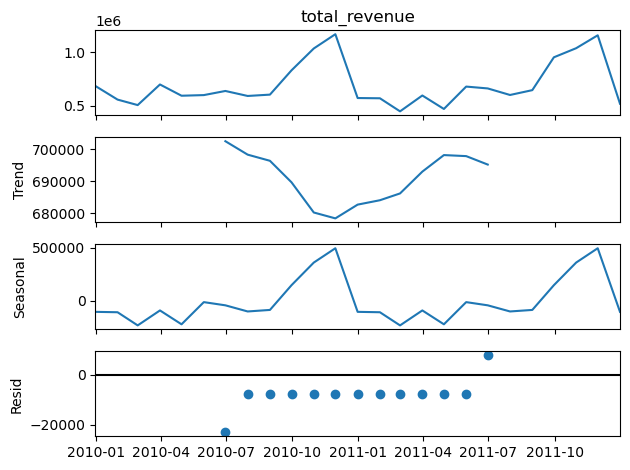

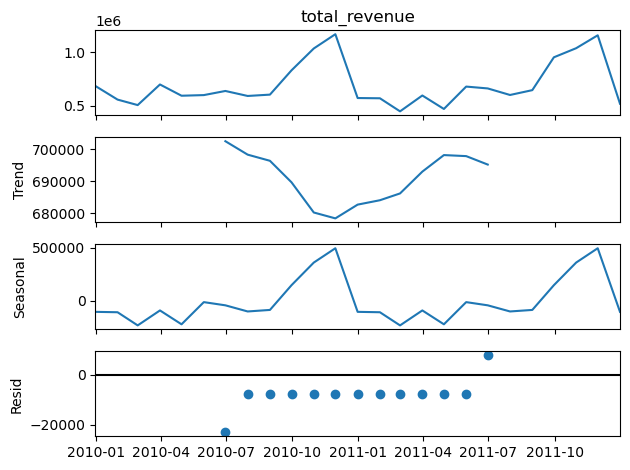

In [9]:
components.plot()

In [10]:
trend = components.trend

In [11]:
seasonality = components.seasonal

In [12]:
remainder = components.resid

In [13]:
# SECTION 2 — STATIONARITY CHECK
# Checking for stationarity
# Testing for stationarity
# ADF Test


# Visual Check

<Axes: xlabel='date'>

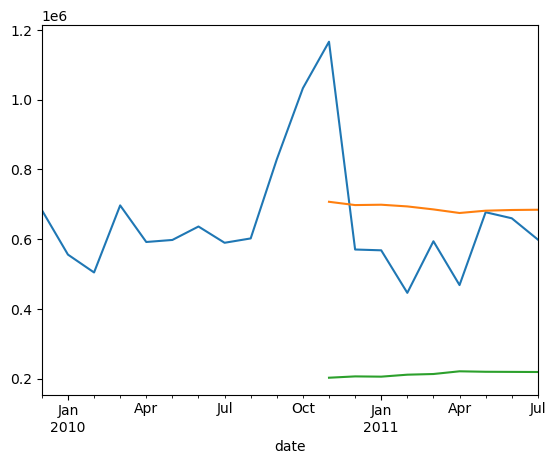

In [14]:
train.plot()
train.rolling(window = 12).mean().plot()
train.rolling(window = 12).std().plot()

In [15]:
# 2.2 ADF Test
# H0: series is NOT stationary → reject if p-value < 0.05
adf_test = adfuller(train, autolag='AIC')
print("=" * 45)
print("ADF Test Results")
print("=" * 45)
print(f"  ADF Statistic : {round(adf_test[0], 3)}")
print(f"  p-value       : {round(adf_test[1], 3)}")
print(f"  Stationary    : {'Yes ✓' if adf_test[1] < 0.05 else 'No ✗ → consider differencing'}")
print("  Critical Values:")
for key, value in adf_test[4].items():
    print(f"    {key}: {round(value, 3)}")

ADF Test Results
  ADF Statistic : -14.355
  p-value       : 0.0
  Stationary    : Yes ✓
  Critical Values:
    1%: -4.223
    5%: -3.189
    10%: -2.73


In [16]:
# SECTION 3 — ACF & PACF PLOTS
# ACF  → helps identify q (MA order)
# PACF → helps identify p (AR order)


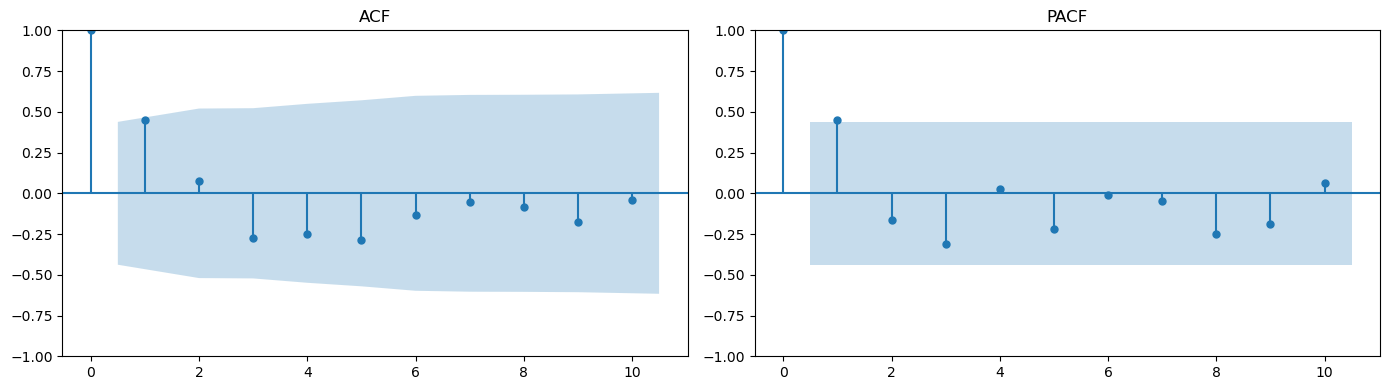

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train, ax=axes[0], title="ACF")
plot_pacf(train, ax=axes[1], title="PACF")
plt.tight_layout()
plt.show()

In [18]:
# SECTION 4 — BASELINE MODELS (MA, AR, ARMA, ARIMA)

baseline_orders = {
    "MA(0,0,1)":    (0, 0, 1),
    "AR(1,0,0)":    (1, 0, 0),
    "ARMA(1,0,1)":  (1, 0, 1),
    "ARIMA(1,1,1)": (1, 1, 1),
}
print("\n" + "=" * 45)
print("Baseline Model AIC Scores")
print("=" * 45)
for name, order in baseline_orders.items():
    model  = sm.tsa.statespace.SARIMAX(train, order=order)
    result = model.fit(disp=False)
    print(f"  {name:<18} AIC: {round(result.aic, 2)}")



Baseline Model AIC Scores
  MA(0,0,1)          AIC: 586.26
  AR(1,0,0)          AIC: 547.64
  ARMA(1,0,1)        AIC: 549.3
  ARIMA(1,1,1)       AIC: 518.75


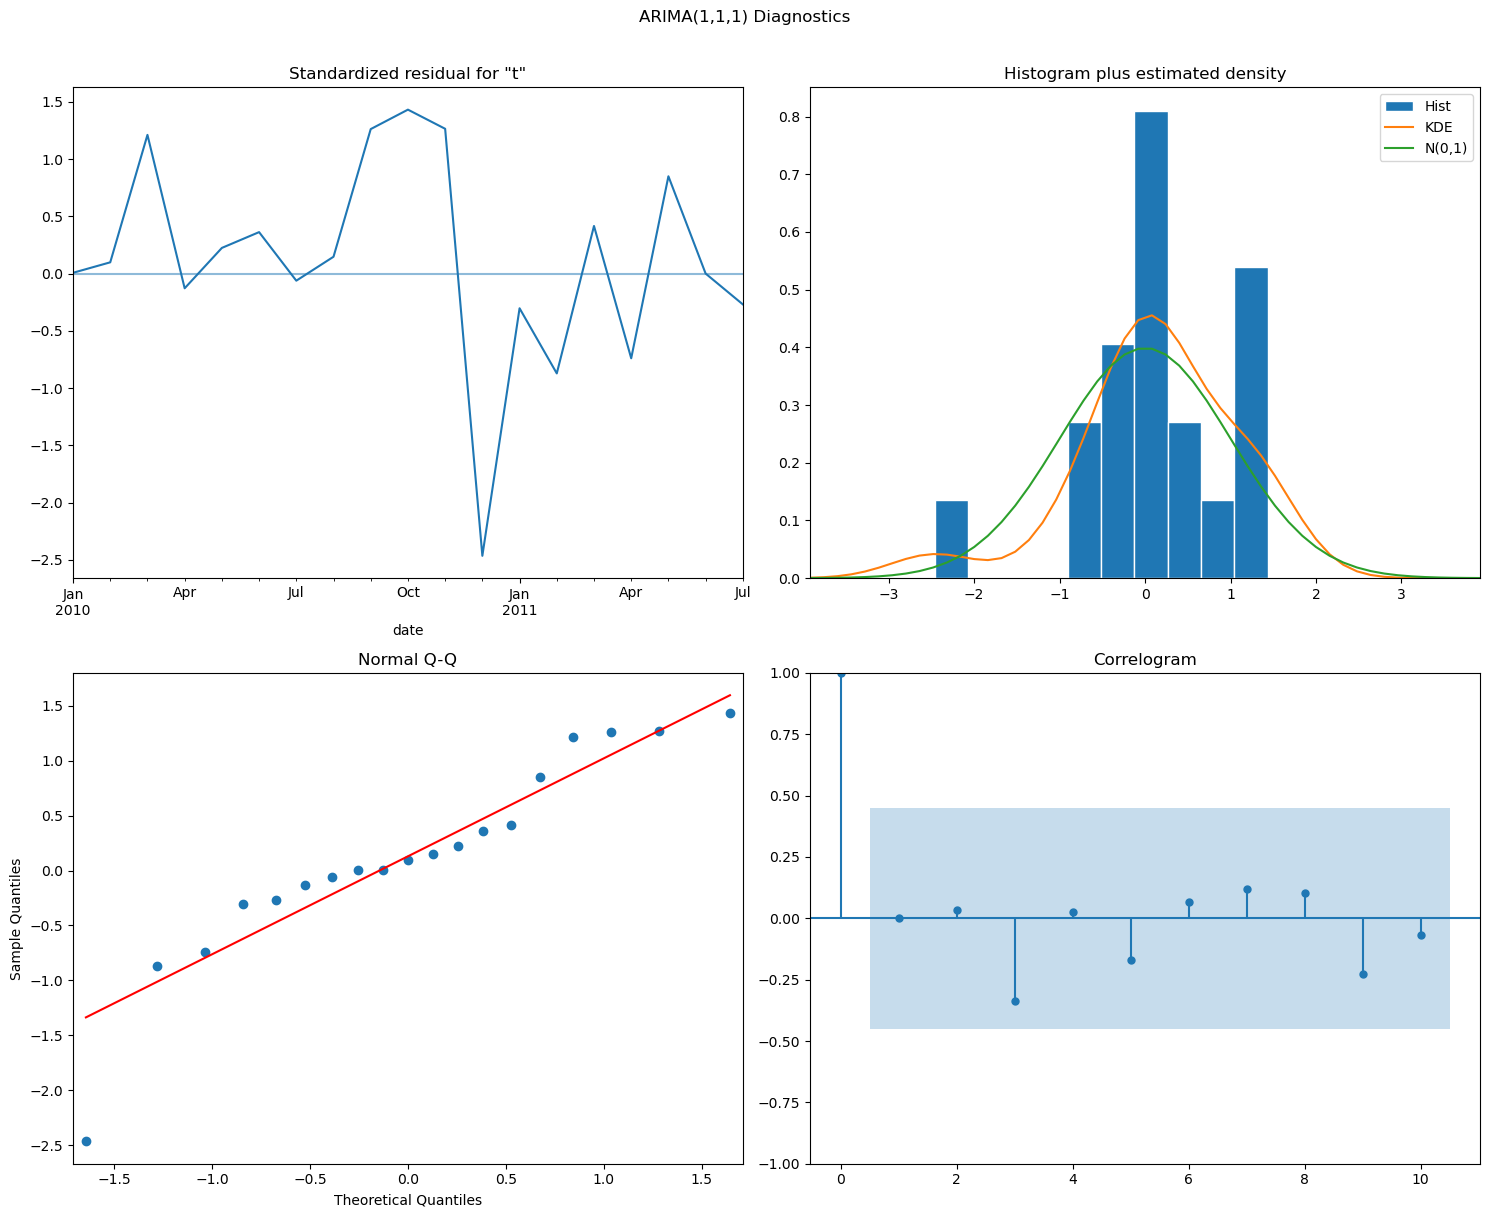

In [19]:
# Diagnostics for ARIMA(1,1,1)
model_arima_base    = sm.tsa.statespace.SARIMAX(train, order=(1, 1, 1))
results_arima_base  = model_arima_base.fit(disp=False)
results_arima_base.plot_diagnostics(figsize=(15, 12))
plt.suptitle("ARIMA(1,1,1) Diagnostics", y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# SECTION 5 — SARIMA GRID SEARCH
# SARIMA(p,d,q)(P,D,Q)[S=12]
# Goal: find the combination with the lowest AIC

S = 12
p = d = q = range(0, 2)
P = Q   = range(0, 2)   
D       = range(0, 2)      

combinations = list(itertools.product(p, d, q, P, D, Q))
print(f"\nTotal SARIMA combinations to evaluate: {len(combinations)}")

results_list = []

for combo in combinations:
    p_, d_, q_, P_, D_, Q_ = combo
    if p_ + d_ + q_ + P_ + D_ + Q_ == 0:   # ← ADD THIS: skip null model
        continue
    try:
        model = sm.tsa.statespace.SARIMAX(
            train,
            order=(p_, d_, q_),
            seasonal_order=(P_, D_, Q_, S),
            enforce_stationarity=True,
            enforce_invertibility=True,
        )
        result = model.fit(disp=False)
        results_list.append({
            'p': p_, 'd': d_, 'q': q_,
            'P': P_, 'D': D_, 'Q': Q_,
            'AIC': result.aic
        })
    except Exception:
        continue

results_data        = pd.DataFrame(results_list)
results_data['AIC'] = results_data['AIC'].astype(float)
best_row            = results_data.loc[results_data['AIC'].idxmin()]
print("\nBest SARIMA Model by AIC:")
print(best_row)


Total SARIMA combinations to evaluate: 64

Best SARIMA Model by AIC:
p        1.000000
d        1.000000
q        0.000000
P        0.000000
D        1.000000
Q        0.000000
AIC    182.545537
Name: 49, dtype: float64


In [21]:
# SECTION 6 — FIT BEST SARIMA MODEL

best_order    = (int(best_row.p), int(best_row.d), int(best_row.q))
best_seasonal = (int(best_row.P), int(best_row.D), int(best_row.Q), S)

best_sarima_model   = sm.tsa.statespace.SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal
)
results_sarima = best_sarima_model.fit(disp=False)
print(results_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      total_revenue   No. Observations:                   20
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                 -89.273
Date:                            Wed, 22 Apr 2026   AIC                            182.546
Time:                                    19:05:19   BIC                            182.437
Sample:                                12-31-2009   HQIC                           181.208
                                     - 07-31-2011                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1056      0.455     -0.232      0.816      -0.997       0.786
sigma2      7.723e+09   1.92e-11   

In [22]:
print(f"Best order:    {best_order}")
print(f"Best seasonal: {best_seasonal}")
print(f"Data length:   {len(train)}")

Best order:    (1, 1, 0)
Best seasonal: (0, 1, 0, 12)
Data length:   20


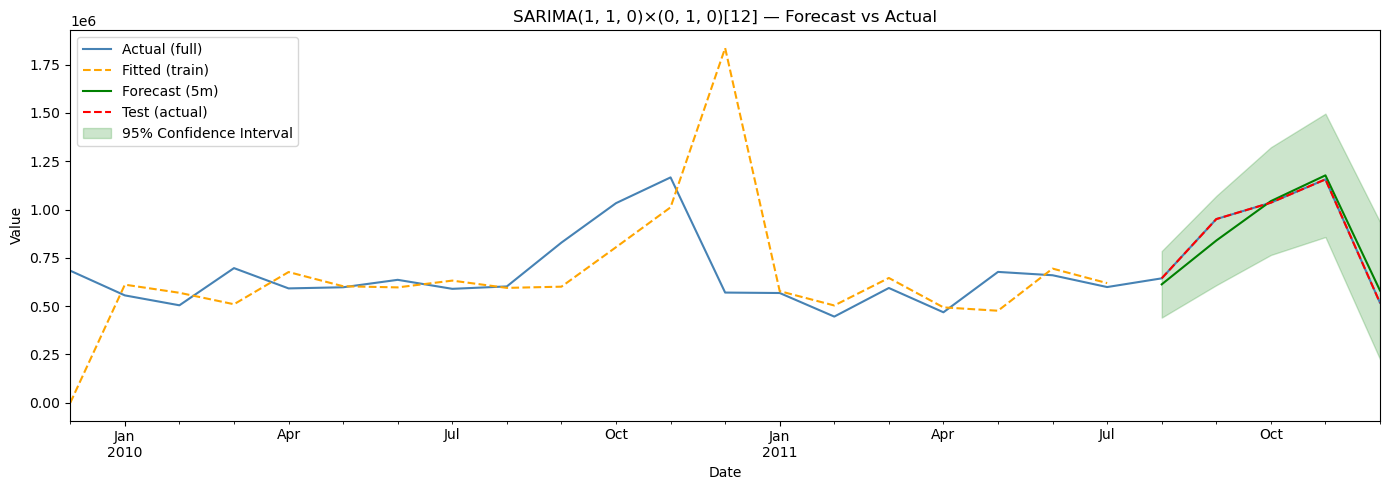

In [23]:
# SECTION 7 — SARIMA FORECAST


fitting_sarima      = results_sarima.get_prediction(start=train.index[0])
fitting_sarima_mean = fitting_sarima.predicted_mean

forecast_sarima      = results_sarima.get_forecast(steps=5) 
forecast_sarima_mean = forecast_sarima.predicted_mean
forecast_sarima_ci   = forecast_sarima.conf_int()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
monthly_series.plot(ax=ax, label='Actual (full)', color='steelblue')
fitting_sarima_mean.plot(ax=ax, label='Fitted (train)', color='orange', linestyle='--')
forecast_sarima_mean.plot(ax=ax, label='Forecast (5m)', color='green')
test.plot(ax=ax, label='Test (actual)', color='red', linestyle='--')
ax.fill_between(
    forecast_sarima_ci.index,
    forecast_sarima_ci.iloc[:, 0],
    forecast_sarima_ci.iloc[:, 1],
    alpha=0.2, color='green', label='95% Confidence Interval'
)
ax.set_title(f"SARIMA{best_order}×{best_seasonal[:3]}[{S}] — Forecast vs Actual")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
# SECTION 8 — MODEL EVALUATION (Out-of-Sample Accuracy)
# Comparing forecast vs actual test values


import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# ── SARIMA forecast on test set ───────────────────────────────────────────────
forecast_sarima_test = results_sarima.get_forecast(steps=len(test)).predicted_mean

# ── Baseline ARIMA(1,1,1) forecast on test set ───────────────────────────────
model_baseline   = sm.tsa.statespace.SARIMAX(train, order=(1, 1, 1))
result_baseline  = model_baseline.fit(disp=False)
forecast_baseline = result_baseline.get_forecast(steps=len(test)).predicted_mean

# ── Compute metrics ──────────────────────────────────────────────────────────
def compute_metrics(actual, predicted, label):
    mae  = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    rmse = np.sqrt(np.mean((actual.values - predicted.values) ** 2))
    print(f"  {label:<35} MAE: {round(mae,2):<12} MAPE: {round(mape,2):<8}%  RMSE: {round(rmse,2)}")
    return mae, mape, rmse

print("\n" + "=" * 75)
print("Model Evaluation — Out-of-Sample (Test Set)")
print("=" * 75)
compute_metrics(test, forecast_sarima_test,  f"Best SARIMA{best_order}×{best_seasonal[:3]}")
compute_metrics(test, forecast_baseline,      "Baseline ARIMA(1,1,1)")


Model Evaluation — Out-of-Sample (Test Set)
  Best SARIMA(1, 1, 0)×(0, 1, 0)      MAE: 46983.75     MAPE: 6.29    %  RMSE: 59798.02
  Baseline ARIMA(1,1,1)               MAE: 287511.81    MAPE: 29.6    %  RMSE: 345442.52


(287511.8104205107, 29.602826870992498, np.float64(345442.5221972186))

In [25]:
# SECTION 9 — BEST HOLT-WINTERS FORECAST

In [26]:
hw_configs = {
    "HW — Add Trend + Add Seasonal": {"trend": "add", "seasonal": "add"},
    "HW — Mul Trend + Add Seasonal": {"trend": "mul", "seasonal": "add"},
    "HW — Add Trend + Mul Seasonal": {"trend": "add", "seasonal": "mul"},
    "HW — Mul Trend + Mul Seasonal": {"trend": "mul", "seasonal": "mul"},
}

In [27]:
hw_results = {}
hw_fits    = {}

In [28]:
for name, config in hw_configs.items():
    model  = ExponentialSmoothing(
        monthly_series,
        trend=config["trend"],
        seasonal=config["seasonal"],
        seasonal_periods=12
    )
    result         = model.fit()
    hw_results[name] = result
    hw_fits[name]    = result.fittedvalues


In [29]:
def evaluate(actual, fitted, label):
    aligned        = actual.align(fitted, join='inner')
    actual_aligned = aligned[0]
    fitted_aligned = aligned[1].reindex(actual_aligned.index).dropna()
    actual_aligned = actual_aligned.loc[fitted_aligned.index]
    mae_val  = mean_absolute_error(actual_aligned, fitted_aligned)
    mape_val = mean_absolute_percentage_error(actual_aligned, fitted_aligned) * 100
    print(f"  {label:<40} MAE: {round(mae_val, 2):<10} MAPE: {round(mape_val, 2)}%")
    return mae_val, mape_val


In [30]:
# Holt-Winters models
for name, result in hw_results.items():
    evaluate(monthly_series, result.fittedvalues, name)

  HW — Add Trend + Add Seasonal            MAE: 35853.83   MAPE: 5.41%
  HW — Mul Trend + Add Seasonal            MAE: 35818.39   MAPE: 5.4%
  HW — Add Trend + Mul Seasonal            MAE: 33781.76   MAPE: 5.26%
  HW — Mul Trend + Mul Seasonal            MAE: 32851.95   MAPE: 5.18%


  HW — Add Trend + Add Seasonal            MAE: 35853.83   MAPE: 5.41%
  HW — Mul Trend + Add Seasonal            MAE: 35818.39   MAPE: 5.4%
  HW — Add Trend + Mul Seasonal            MAE: 33781.76   MAPE: 5.26%
  HW — Mul Trend + Mul Seasonal            MAE: 32851.95   MAPE: 5.18%
Best HW Model: HW — Mul Trend + Mul Seasonal (MAPE: 5.18%)


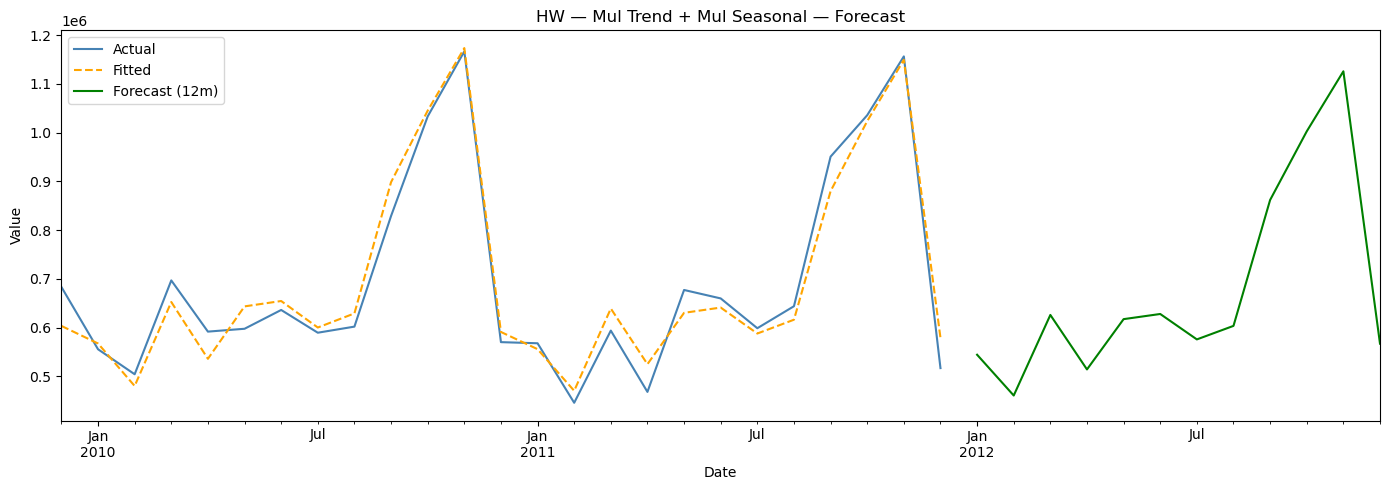

In [31]:
# Auto-select best HW model based on lowest MAPE
hw_mape_scores = {}
for name, result in hw_results.items():
    _, mape = evaluate(monthly_series, result.fittedvalues, name)
    hw_mape_scores[name] = mape

best_hw_name = min(hw_mape_scores, key=hw_mape_scores.get)
print(f"Best HW Model: {best_hw_name} (MAPE: {round(hw_mape_scores[best_hw_name], 2)}%)")

best_hw_result = hw_results[best_hw_name]

forecast_hw = best_hw_result.forecast(steps=12)

fig, ax = plt.subplots(figsize=(14, 5))
monthly_series.plot(ax=ax, label='Actual', color='steelblue')
best_hw_result.fittedvalues.plot(ax=ax, label='Fitted', color='orange', linestyle='--')
forecast_hw.plot(ax=ax, label='Forecast (12m)', color='green')
ax.set_title(f"{best_hw_name} — Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()